# **Import Libraries**

In [24]:
!pip install ydata-profiling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# **Upload Dataset**

In [26]:
df = pd.read_csv("holistic_dataset.csv")
df.head()

,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
0,1,56.0,Other,South,Secondary,Self-Employed,51778.0,415482,Business,828.0,8,58,0.533248,2018-01-01,0
1,2,46.0,Female,North,Graduate,Salaried,178806.0,222400,Business,465.0,4,78,0.727160,2018-01-02,1
2,3,32.0,Other,South,Graduate,Salaried,174245.0,222060,Business,795.0,2,75,0.667660,2018-01-03,1
3,4,60.0,Female,North,Primary,NaN,181475.0,394959,Education,728.0,4,42,1.477725,2018-01-04,0
4,5,NaN,Other,East,Graduate,Salaried,157416.0,441742,Education,462.0,9,38,0.509149,2018-01-05,0


# **Data Understanding**

In [27]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        800 non-null    int64  
 1   age                720 non-null    float64
 2   gender             800 non-null    object 
 3   region             800 non-null    object 
 4   education_level    800 non-null    object 
 5   employment_type    720 non-null    object 
 6   annual_income      720 non-null    float64
 7   loan_amount        800 non-null    int64  
 8   loan_purpose       800 non-null    object 
 9   credit_score       720 non-null    float64
 10  repayment_history  800 non-null    int64  
 11  transaction_count  800 non-null    int64  
 12  spending_ratio     800 non-null    float64
 13  join_date          800 non-null    object 
 14  default_flag       800 non-null    int64  
dtypes: float64(4), int64(5), object(6)
memory usage: 93.9+ KB


,customer_id,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio,default_flag
count,800.0000,720.000000,720.000000,800.00000,720.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,41.345833,111478.887500,264715.47250,581.880556,4.563750,51.860000,0.800751,0.491250
std,231.0844,13.415521,52254.052489,142830.80173,158.413228,2.926883,28.208377,0.406339,0.500236
min,1.0000,18.000000,20159.000000,5192.00000,300.000000,0.000000,1.000000,0.105486,0.000000
25%,200.7500,30.000000,66140.750000,136608.50000,446.000000,2.000000,28.000000,0.447314,0.000000
50%,400.5000,42.000000,110288.000000,274142.00000,586.000000,5.000000,53.000000,0.796453,0.000000
75%,600.2500,52.000000,159122.750000,388305.75000,722.250000,7.000000,76.000000,1.159050,1.000000
max,800.0000,64.000000,199767.000000,498992.00000,849.000000,9.000000,99.000000,1.499245,1.000000


# **Check Missing Values**

In [28]:
df.isnull().sum()

,0
customer_id,0
age,80
gender,0
region,0
education_level,0
employment_type,80
annual_income,80
loan_amount,0
loan_purpose,0
credit_score,80


# **Handle Missing Values**

In [29]:
from sklearn.impute import SimpleImputer

# Numerical
num_cols = df.select_dtypes(include=np.number).columns

imputer = SimpleImputer(strategy='mean')
df[num_cols] = imputer.fit_transform(df[num_cols])

# Categorical
cat_cols = df.select_dtypes(include='object').columns

imputer_cat = SimpleImputer(strategy='most_frequent')
df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

# **Remove Duplicates**

In [30]:
df.drop_duplicates(inplace=True)

# **Date Handling**

In [31]:
df['join_date'] = pd.to_datetime(df['join_date'])

df['year'] = df['join_date'].dt.year
df['month'] = df['join_date'].dt.month
df['day'] = df['join_date'].dt.day

# **Outlier Handling (IQR Method)**

In [32]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

# **Encoding**

In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
if 'gender' in df.columns:
    df['gender'] = le.fit_transform(df['gender'])

In [34]:
df = pd.get_dummies(df, drop_first=True)

# **Feature Engineering**

In [35]:
df['debt_income_ratio'] = df['loan_amount'] / (df['annual_income'] + 1)

# **Scaling**

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = df.select_dtypes(include=np.number).columns
num_cols = num_cols.drop('default_flag')

df[num_cols] = scaler.fit_transform(df[num_cols])

# **EDA**
**Histogram**

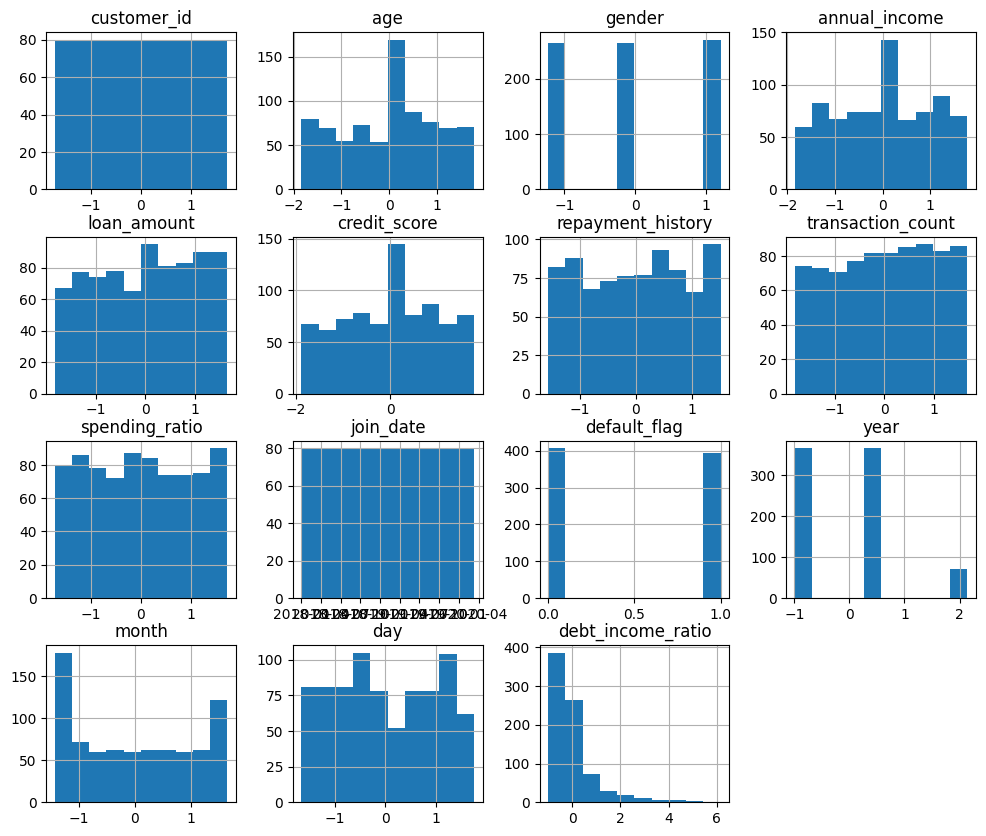

In [37]:
df.hist(figsize=(12,10))
plt.show()

**Heatmap**

<Axes: >

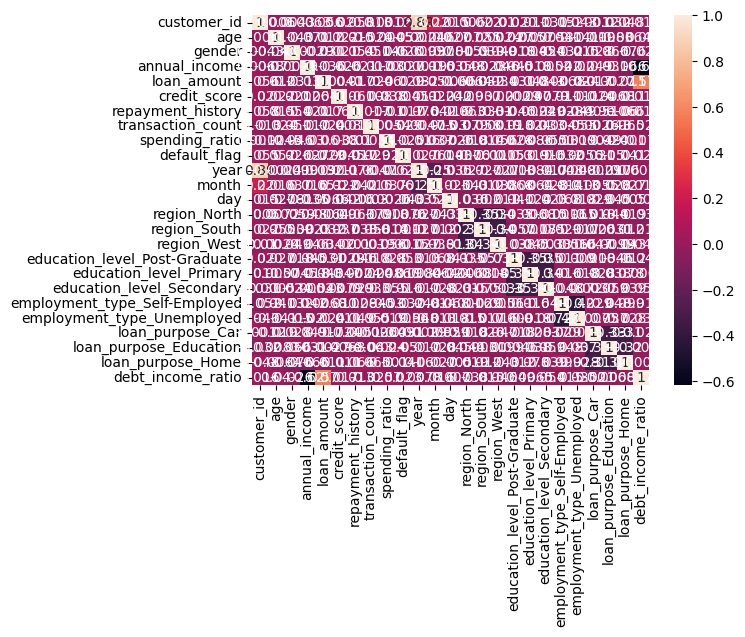

In [38]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

**Pairplot**

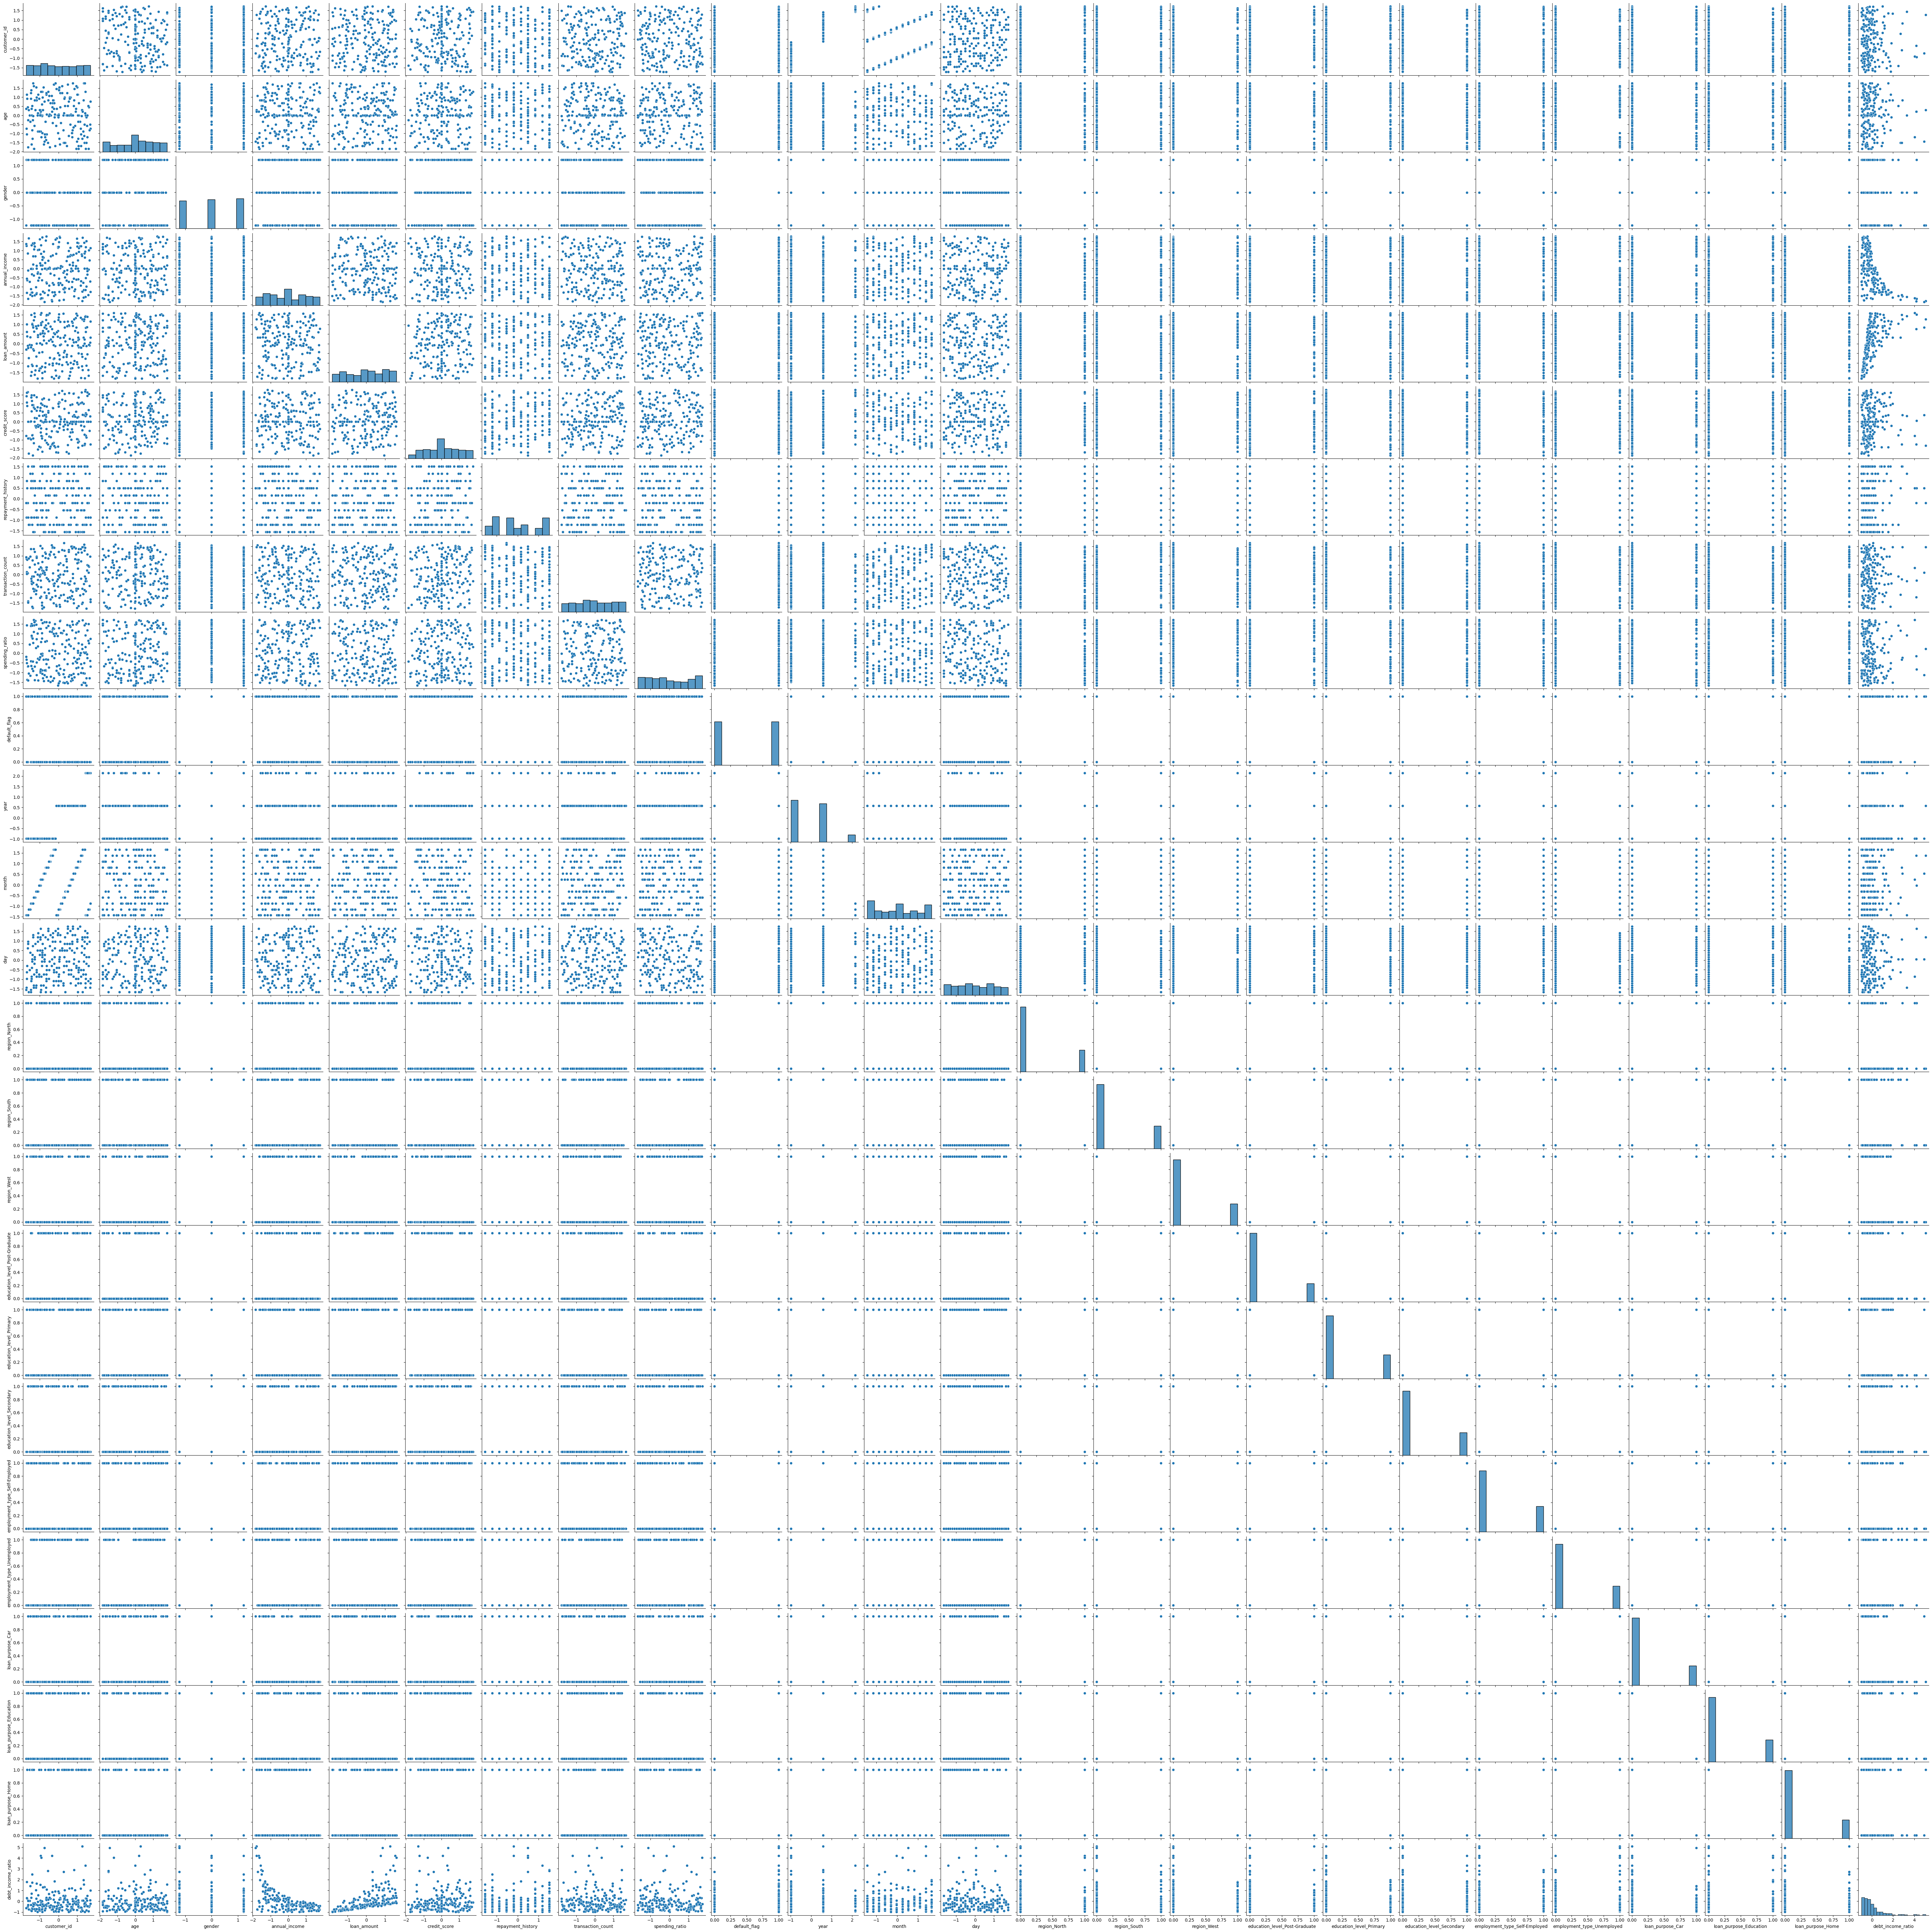

In [43]:
sns.pairplot(df.sample(200))
plt.show()

# **Data Profiling**

In [40]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df)
profile.to_file("final_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 26/26 [00:00<00:00, 43.72it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# **Save Final Dataseta**

In [41]:
df.to_csv("cleaned_data.csv", index=False)

# **Insights (VERY IMPORTANT)**

In [42]:
print("Insights:")
print("1. Missing values handled using mean and mode")
print("2. Outliers treated using IQR method")
print("3. Encoding applied to categorical variables")
print("4. Debt to Income ratio created as new feature")
print("5. Dataset is now ready for machine learning")

Insights:
1. Missing values handled using mean and mode
2. Outliers treated using IQR method
3. Encoding applied to categorical variables
4. Debt to Income ratio created as new feature
5. Dataset is now ready for machine learning
